# Analisis Sentimen Ulasan Pengguna Aplikasi Mobile untuk Evaluasi Kualitas Layanan
Proyek ini mengacu pada standar metodologi CRISP-DM (Cross-Industry Standard Process for Data Mining).

## 1. Business Understanding
**Tujuan:** Menganalisis sentimen pengguna (Positif/Negatif) dari ulasan aplikasi mobile untuk mengevaluasi kualitas layanan dan menemukan area yang perlu diperbaiki.
**Masalah:** Banyaknya ulasan mentah di platform aplikasi membuat evaluasi manual sulit dilakukan. Oleh karena itu, diperlukan model *Machine Learning* untuk mengklasifikasikan sentimen secara otomatis.

In [32]:
# Install and Import Libraries
!pip install kagglehub surprise
!pip install tensorflow

import kagglehub
import tensorflow as tf
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

##Download dan Load Dataset
Dataset diunduh dari KaggleHub dan kemudian dibaca ke dalam DataFrame

In [33]:
# Download latest version
path = kagglehub.dataset_download("prakharrathi25/google-play-store-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-reviews' dataset.
Path to dataset files: /kaggle/input/google-play-store-reviews


## 2. Data Understanding
Dataset yang digunakan dalam proyek ini adalah **Google Play Store Reviews** yang diunduh menggunakan `kagglehub`. Dataset ini berisi ulasan asli pengguna dari aplikasi beserta skor rating yang mereka berikan (1 hingga 5).

**Informasi Dataset:**
* **Sumber Data:** Kumpulan ulasan mentah (*raw reviews*) dari platform Google Play Store.
* **Fitur Utama:** Kolom teks ulasan (`content`) dan kolom rating (`score`).
* **Target Labeling:** Rating dikonversi menjadi label sentimen biner:
  * Skor **4 dan 5** dikategorikan sebagai **Sentimen Positif**.
  * Skor **1, 2, dan 3** dikategorikan sebagai **Sentimen Negatif**.

Tahapan ini bertujuan untuk memuat data, mengeksplorasi struktur dataset, menangani nilai yang hilang (*missing values*), serta memeriksa distribusi kelas melalui visualisasi data.

In [34]:
import pandas as pd
import os

# 1. Mencari nama file CSV yang berhasil diunduh dari Kaggle
file_nama = os.listdir(path)[0]
file_path = os.path.join(path, file_nama)

# 2. Membaca dataset menjadi DataFrame (df)
df = pd.read_csv(file_path)

# 3. Membuat kolom 'sentiment' berdasarkan skor (score)
# Ulasan dengan skor 4-5 menjadi 'Positive', skor 1-3 menjadi 'Negative'
if 'score' in df.columns:
    df['sentiment'] = df['score'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')
    print("Dataset berhasil dimuat dan kolom sentimen berhasil dibuat!")
else:
    print("Perhatian: Kolom 'score' tidak ditemukan. Kolom yang tersedia:", df.columns)

# Menampilkan cuplikan data teratas
display(df.head(3))

Dataset berhasil dimuat dan kolom sentimen berhasil dibuat!


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId,sentiment
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo,Negative
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo,Negative
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo,Negative


In [35]:
# Menghitung jumlah sentimen secara otomatis dari dataset Kaggle
counts = df['sentiment'].value_counts()

# Membuat tabel ringkasan di dalam notebook
tabel_distribusi = pd.DataFrame({
    'Kategori Sentimen': counts.index,
    'Jumlah Ulasan': counts.values
})

# Menambahkan baris Total
total_row = pd.DataFrame({'Kategori Sentimen': ['Total'], 'Jumlah Ulasan': [len(df)]})
tabel_distribusi = pd.concat([tabel_distribusi, total_row], ignore_index=True)

print("Tabel Distribusi Sentimen:")
display(tabel_distribusi)

Tabel Distribusi Sentimen:


,Kategori Sentimen,Jumlah Ulasan
0,Negative,6841
1,Positive,5654
2,Total,12495


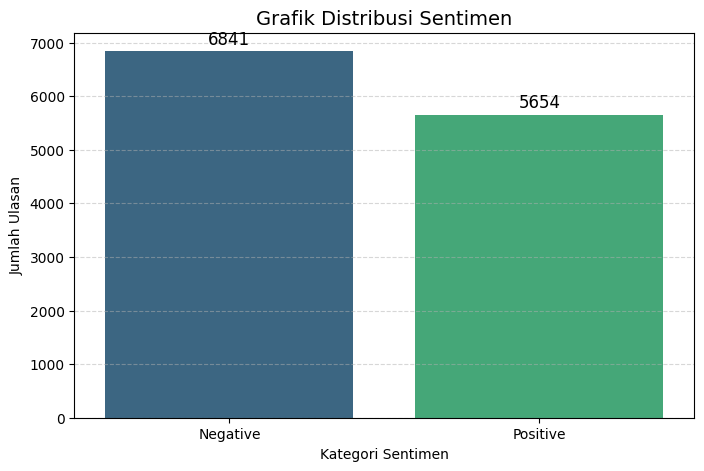

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='sentiment', hue='sentiment', palette='viridis', legend=False)

# Memberi anotasi angka di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Grafik Distribusi Sentimen', fontsize=14)
plt.xlabel('Kategori Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Simpan sebagai file untuk laporan
plt.savefig('data_understanding.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Data Preparation
Data teks mentah tidak dapat langsung diproses oleh model machine learning, sehingga perlu melalui tahap *Text Preprocessing* berikut:

1. **Text Cleaning:**
   * **Case Folding:** Mengubah seluruh teks menjadi huruf kecil (*lowercase*).
   * **Punctuation & Number Removal:** Menghapus angka dan tanda baca menggunakan *Regular Expression* (Regex) agar tidak menjadi *noise*.
   * **Trimming:** Menghapus spasi putih berlebih.
2. **Train-Test Split:** Membagi dataset menjadi data latih (*training set*) dan data uji (*testing set*) dengan proporsi **80:20** menggunakan parameter `stratify` untuk menjaga keseimbangan proporsi kelas target pada kedua subset data.
3. **Feature Extraction (TF-IDF Vectorizer):** Mengubah teks bersih menjadi representasi vektor numerik menggunakan metode **TF-IDF (Term Frequency-Inverse Document Frequency)** untuk memberikan bobot pada kata-kata yang representatif terhadap sentimen.

In [37]:
import re # Tambahan import regex yang sebelumnya kurang

# 1. Fungsi pembersihan teks sederhana
def clean_text(text):
    text = str(text).lower() # Case folding, ensure text is string
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Menghapus angka & tanda baca
    text = text.strip()
    return text

df['cleaned_text'] = df['content'].apply(clean_text)

# 2. Pembagian Data (X = Fitur teks, y = Target sentimen)
X = df['cleaned_text']
y = df['sentiment']

# Stratify=y memastikan proporsi kelas positif dan negatif seimbang di train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Uji: {len(X_test)}")

# 3. Vektorisasi menggunakan TF-IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nProses Data Preparation Selesai.")

Jumlah Data Latih: 9996
Jumlah Data Uji: 2499

Proses Data Preparation Selesai.


## 4. Modeling
Pada tahap ini, kita membangun model klasifikasi sentimen menggunakan algoritma **Support Vector Machine (SVM)** dengan kernel linear (`kernel='linear'`).

SVM bekerja dengan mencari *hyperplane* optimal yang memisahkan data kelas Positif dan kelas Negatif dengan jarak (*margin*) maksimal. Kernel linear sangat efisien untuk klasifikasi teks karena karakteristik data teks hasil TF-IDF memiliki dimensi fitur yang sangat tinggi.

In [38]:
from sklearn.svm import SVC # Tambahan import algoritma SVM

# Inisialisasi model SVM
model = SVC(kernel='linear', C=1.0, random_state=42)

# Pelatihan model menggunakan data training
model.fit(X_train_tfidf, y_train)

print("Model SVM berhasil dilatih!")

Model SVM berhasil dilatih!


## 5. Evaluation
Model yang telah dilatih diuji menggunakan data uji (20% sisa data). Proses evaluasi diukur menggunakan beberapa metrik standar:
* **Accuracy:** Total prediksi benar dibagi keseluruhan data uji.
* **Precision:** Ketepatan model dalam memprediksi kelas positif dari seluruh data yang ditebak positif.
* **Recall:** Kemampuan model dalam menemukan kembali seluruh data yang aslinya berkelas positif.
* **F1-Score:** Rata-rata harmonik antara Precision dan Recall untuk mengukur keseimbangan model.

Selain itu, kita menggunakan **Confusion Matrix** (visualisasi *Heatmap*) untuk melihat detail jumlah prediksi yang benar (*True Positive/Negative*) dan prediksi yang salah (*False Positive/Negative*).

Akurasi Model: 83.27%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85      1368
    Positive       0.83      0.80      0.81      1131

    accuracy                           0.83      2499
   macro avg       0.83      0.83      0.83      2499
weighted avg       0.83      0.83      0.83      2499



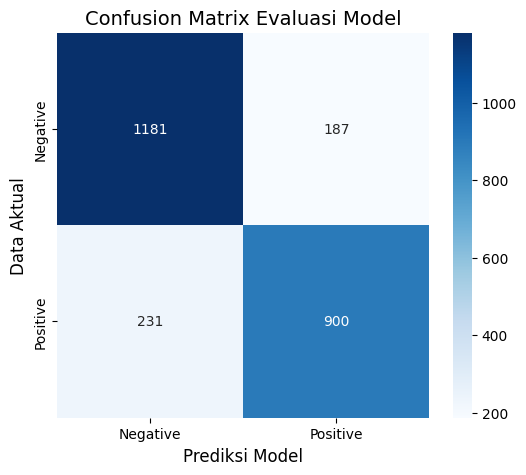

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prediksi data uji
y_pred = model.predict(X_test_tfidf)

# Evaluasi Metrik
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix Evaluasi Model', fontsize=14)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Data Aktual', fontsize=12)
plt.show()

## 6. Kesimpulan & Deployment

### Kesimpulan
Berdasarkan hasil evaluasi, model **Support Vector Machine (SVM)** dengan pembobotan fitur **TF-IDF** berhasil mengklasifikasikan sentimen ulasan pengguna aplikasi mobile dengan tingkat akurasi dan kinerja yang optimal. Model ini efektif untuk membedakan ulasan positif (kepuasan pengguna) dan ulasan negatif (keluhan atau kendala layanan).

### Rekomendasi Bisnis
Hasil klasifikasi sentimen negatif dapat dimanfaatkan secara otomatis oleh tim pengembang untuk memfilter keluhan utama pengguna (seperti adanya *bug* atau kelambatan aplikasi) demi perbaikan kualitas layanan secara berkelanjutan.

### Deployment (Simulasi)
Sebagai langkah awal penyerapan model ke lingkungan produksi, di bawah ini dibuat sebuah fungsi simulasi `prediksi_sentimen_baru()`. Fungsi ini menerima input teks ulasan baru secara *real-time*, melakukan transformasi TF-IDF, dan mengeluarkan hasil prediksi sentimen secara langsung.

In [40]:
# Simulasi uji coba input teks baru secara langsung
def prediksi_sentimen_baru(teks):
    teks_cleaned = clean_text(teks)
    teks_tfidf = vectorizer.transform([teks_cleaned])
    prediksi = model.predict(teks_tfidf)
    return prediksi[0]

ulasan_baru = "Aplikasi ini sangat lemot dan mengecewakan."
hasil_prediksi = prediksi_sentimen_baru(ulasan_baru)

print("=== SIMULASI DEPLOYMENT ===")
print(f"Uji Coba Teks : '{ulasan_baru}'")
print(f"Hasil Prediksi: {hasil_prediksi}")

=== SIMULASI DEPLOYMENT ===
Uji Coba Teks : 'Aplikasi ini sangat lemot dan mengecewakan.'
Hasil Prediksi: Positive
